In [1]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()
#데이터 CSV 파일 읽어오기

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [29]:
print(pd.unique(fish['Species'])) #.unique: 중복을 제거하고 고유값만 뽑아주는 것
fish_input=fish[['Weight','Length','Diagonal','Height','Width']] #데이터프레임에서 특정 열(column)들만 골라서 새로운 데이터 만들기
fish_input.head() #앞의 5개 행만 출력
#Species 열만 출력해서 이름확인하기 + Species 열 제외한 나머지 5개의 열 확인하기

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [3]:
fish_target=fish['Species'] #Species 열을 가져와서 정답데이터로 구성하는 것

from sklearn.model_selection import train_test_split #데이터를 훈련용(train)과 테스트용(test)으로 나누는 함수
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)  #데이터를 훈련용(train)과 테스트용(test)으로 나누는 함수
#42는 큰 의미는 없음 랜덤분할을 계속 똑같이 하게 만드는 장치?
#train_test_split 메서드를 사용해 훈련세트와 테스트세트 만들기

In [4]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler() #스케일링
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)
#standardscaler를 이용해서 데이터 전처리 하기

In [5]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))
#가까운 이웃 3개로 하는 가중치 학습

0.8907563025210085
0.85


In [6]:
print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))
#나타날 수 있는 학률 분포 0 1/3 2/3 1

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [7]:
char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

['A' 'C']


In [9]:
bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]
#bream 과 smelt인 경우만 골라내기

In [10]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))
#로지스틱 회귀

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [12]:
print(lr.predict_proba(train_bream_smelt[:5]))
#로지스틱 회귀 모델 훈련 후 5개의 샘플로 예측 확인

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [13]:
print(lr.classes_)
#첫번째 클래스가 bream 두번째 클래스가 smelt

['Bream' 'Smelt']


In [14]:
lr = LogisticRegression(C=20, max_iter=1000) #규제 강도와 최대 반복 횟수
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))
#로지스틱 회귀모델을 사용하여 분류 및 훈련,정확도 확인

0.9327731092436975
0.925


In [15]:
print(lr.predict(test_scaled[:5]))
#예측결과 확인

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [16]:
proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))
#5개의 샘플에 대한 결과

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [17]:
print(lr.coef_.shape,lr.intercept_.shape) #가중치와 절편의 크기 출력

(7, 5) (7,)


In [18]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')
#데이터셋 준비

In [19]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']
#입력과 타겟으로 분류

In [20]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)
#train_test_split 함수를 사용해서 훈련세트와 테스트세트로 분리

In [21]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)
#표점 정규화

In [23]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))
#모델 훈련 후 정확도 확인
#훈련수가 부족해서 정확도가 아직 불만족 스러움

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [24]:
sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target)) #기존 학습 결과를 이어서 추가 학습
#이전보단 개선되었으나 아직 부족함

0.7983193277310925
0.775


In [25]:
import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)
#모델생성후 훈련점수와 테스트 점수를 담을 배열 만들기

In [26]:
for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))
    #300번 훈련 후 매 에포크마다 훈련, 테스트 점수를 기록

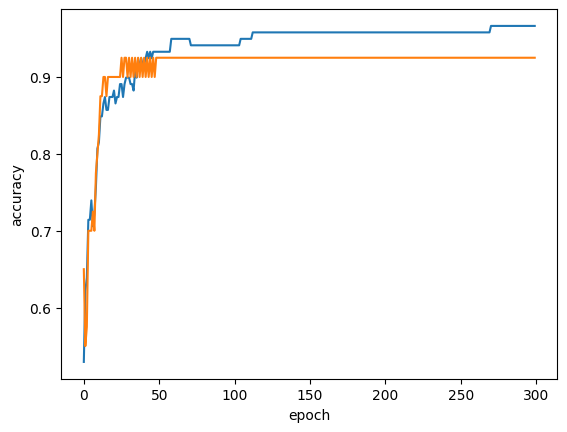

In [27]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()
#100이후부터 훈련점수와 테스트 점수가 벌어지는것으로 보아 100번 정도가 가장 적절함

In [28]:
sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))
#에포크를 100으로 설정하고 훈련한 결과 훈련과 테스트 세트의 높은 점수를 확인할 수 있다.

0.957983193277311
0.925


In [ ]:
# 1번 과제
'''
과제 설명: 로지스틱 회귀 모델을 사용해 새로운 데이터셋에 대한 예측 결과 출력

과제 순서:
fish=pd.read_csv('http://bit.ly/fish_csv_data')
1. 위의 코드를 사용해 데이터셋을 가져오기
2, 가져온 데이터셋을 테스트 세트와 훈련 세트로 분리 (당연히 먼저 입력과 타깃부터 분리해야겠죠?)
3. 표준 정규화
4. 로지스틱 회귀 모델 훈련
5. 로지스틱 회귀 모델로 새로운 데이터셋 예측값 출력
6. 각 예측 결과에 대한 7종의 물고기 별 확률 출력
'''
# 새로운 데이터 셋
'''
test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])
'''
# AI의 도움을 받으시는것도 좋습니다 그러나 코드의 구성과 결과에 대해서는 정확히 알고 계시는걸 추천합니다

In [37]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']
#데이터셋을 가져오기

In [31]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)
#데이터셋을 테스트 세트와 훈련 세트로 분리

In [32]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)
#표준 정규화

In [35]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled,train_target)
#로지스틱 회귀 모델 훈련

LogisticRegression(C=20, max_iter=1000)

In [36]:
print(lr.predict(test_scaled))
#로지스틱 회귀 모델로 새로운 데이터셋 예측값 출력

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch' 'Bream' 'Smelt' 'Roach' 'Perch'
 'Pike' 'Bream' 'Perch' 'Bream' 'Parkki' 'Bream' 'Bream' 'Perch' 'Perch'
 'Perch' 'Bream' 'Smelt' 'Bream' 'Bream' 'Bream' 'Bream' 'Perch' 'Perch'
 'Roach' 'Smelt' 'Smelt' 'Pike' 'Perch' 'Perch' 'Pike' 'Bream' 'Perch'
 'Roach' 'Roach' 'Parkki' 'Perch']


In [34]:
proba=lr.predict_proba(test_scaled)
print(np.round(proba,decimals=3))
#각 예측 결과에 대한 7종의 물고기 별 확률 출력

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]
 [0.999 0.    0.    0.    0.    0.    0.   ]
 [0.    0.001 0.05  0.    0.004 0.945 0.   ]
 [0.001 0.007 0.319 0.014 0.639 0.001 0.018]
 [0.    0.002 0.803 0.002 0.181 0.    0.011]
 [0.    0.    0.022 0.978 0.    0.    0.   ]
 [0.984 0.003 0.    0.    0.001 0.    0.013]
 [0.047 0.    0.817 0.008 0.002 0.    0.126]
 [0.992 0.005 0.    0.    0.    0.    0.003]
 [0.007 0.907 0.002 0.    0.076 0.    0.009]
 [0.999 0.001 0.    0.    0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.    0.   ]
 [0.001 0.    0.936 0.    0.    0.    0.063]
 [0.001 0.003 0.784 0.009 0.19  0.    0.014]
 [0.001 0.035 0.675 0.004 0.263 0.001 0.021]
 [0.991 0.005 0.    0.    0.    0.    0.003]
 [0.    0.002 0.049 0.    0.008 0.941 0.   ]
 [0.997 0.002 0.    0.    0.    0.    0.   ]
 [0.984 0.

In [ ]:
# 2번 과제
'''
과제 설명: SGD classifier 모델을 훈련시키고 최적의 에포크 값을 찾기

과제 순서:
fish=pd.read_csv('http://bit.ly/fish_csv_data')
1. 위의 코드를 사용해 데이터셋을 가져오기
2. SGDclassifier 모델 훈련 (loss 파라미터는 hinge로 설정, 에포크수는 10으로 설정)
3. SGDclassifier 모델 훈련 (loss 파라미터는 hinge로 설정, 에포크수는 300으로 설정)
4. 매 에포크마다 훈련 점수와 테스트 점수 기록
5. 에포크를 x축 정확도를 y축으로 하는 matplotlib 그래프 그리기
6. 눈으로 보고 적절한 에포크 수 찾기
7. 해당 에포크 수로 모델 훈련하고 점수 출력해 2번 과정의 에포크 10인 모델과 정확도 비교
'''
# AI의 도움을 받으시는것도 좋습니다 그러나 코드의 구성과 결과에 대해서는 정확히 알고 계시는걸 추천합니다

In [38]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [56]:
from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss="hinge", random_state=42)
train_scores = []
test_scores = []

for i in range(10):
    sc.partial_fit(train_scaled, train_target, classes=np.unique(train_target))

    train_scores.append(sc.score(train_scaled, train_target))
    test_scores.append(sc.score(test_scaled, test_target))

    print(i+1, train_scores[i], test_scores[i])

1 0.5126050420168067 0.575
2 0.5294117647058824 0.55
3 0.7058823529411765 0.675
4 0.7310924369747899 0.775
5 0.7478991596638656 0.7
6 0.7647058823529411 0.7
7 0.6974789915966386 0.675
8 0.7563025210084033 0.775
9 0.7478991596638656 0.75
10 0.7394957983193278 0.75


In [57]:
train_scores = []
test_scores = []

for i in range(300):
    sc.partial_fit(train_scaled, train_target, classes=np.unique(train_target))

    train_scores.append(sc.score(train_scaled, train_target))
    test_scores.append(sc.score(test_scaled, test_target))

    print(i+1, train_scores[i], test_scores[i])

1 0.8319327731092437 0.9
2 0.7899159663865546 0.8
3 0.8487394957983193 0.875
4 0.8571428571428571 0.875
5 0.8151260504201681 0.825
6 0.8319327731092437 0.9
7 0.773109243697479 0.775
8 0.8067226890756303 0.825
9 0.865546218487395 0.875
10 0.8823529411764706 0.9
11 0.8571428571428571 0.875
12 0.8739495798319328 0.9
13 0.8487394957983193 0.9
14 0.8823529411764706 0.9
15 0.8487394957983193 0.875
16 0.8991596638655462 0.9
17 0.8487394957983193 0.9
18 0.9327731092436975 0.875
19 0.865546218487395 0.925
20 0.8823529411764706 0.9
21 0.8403361344537815 0.9
22 0.8403361344537815 0.9
23 0.8991596638655462 0.9
24 0.907563025210084 0.925
25 0.8823529411764706 0.9
26 0.8907563025210085 0.9
27 0.8571428571428571 0.875
28 0.865546218487395 0.9
29 0.907563025210084 0.925
30 0.8487394957983193 0.875
31 0.9159663865546218 0.925
32 0.9243697478991597 0.925
33 0.865546218487395 0.925
34 0.865546218487395 0.925
35 0.865546218487395 0.925
36 0.8739495798319328 0.95
37 0.907563025210084 0.875
38 0.85714285714

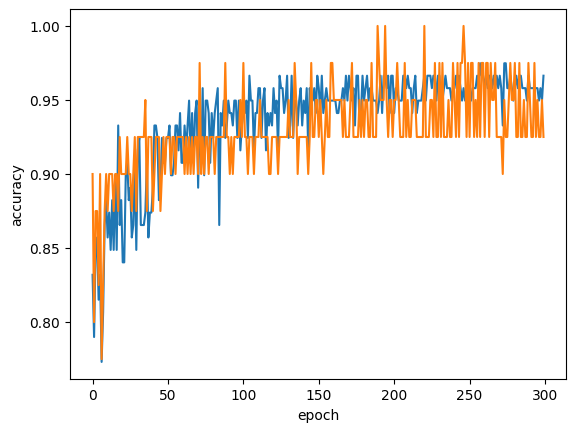

In [59]:
import matplotlib.pyplot as plt
plt.plot(train_scores)
plt.plot(test_scores)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [62]:
from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss="hinge", max_iter = 150, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

#에포크가 10이었던 모델은 0.7394957983193278 0.75 이었던 것으로 보아, 에포크가 150일때의 정확도가 훨씬 개선되었다고 할 수 있다.

0.907563025210084
0.925
